# 21-2. RNN, LSTM, GRU, BiLSTM 비교

21장에서는 LSTM으로 PM10 다음 시간 값을 예측했다.

이번 노트북에서는 같은 window 데이터를 사용하고, 모델 층만 바꿔 비교한다.

비교할 모델은 다음 네 가지다.

```text
SimpleRNN
LSTM
GRU
BiLSTM
```


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, SimpleRNN, LSTM, GRU, Bidirectional, Dense

np.random.seed(42)
tf.random.set_seed(42)


## 데이터 불러오기

21장과 같은 PM10 데이터를 사용한다.

특정 지역 하나를 골라 시간 순서대로 정렬한 뒤, PM10 값만 사용한다.


In [2]:

dataset_path = Path(r"C:\work\dataset\seoul_pm10.csv")
print("데이터 존재 여부:", dataset_path.exists())

df = pd.read_csv(dataset_path, encoding="cp949")

target_area = df["area"].dropna().iloc[0]
area_df = df[df["area"] == target_area].copy()
area_df["date"] = pd.to_datetime(area_df["date"])
area_df = area_df.sort_values("date")

# 결측이 있으면 시간 순서상 앞뒤 값을 이용해 채운다.
area_df["pm10"] = area_df["pm10"].interpolate().ffill().bfill()

values = area_df[["pm10"]].values.astype("float32")

print("선택 지역:", target_area)
print("데이터 모양:", values.shape)
area_df[["date", "area", "pm10"]].head()


데이터 존재 여부: True


선택 지역: 강남구
데이터 모양: (8760, 1)


,date,area,pm10
227734,2022-01-01 00:00:00,강남구,18.0
227708,2022-01-01 01:00:00,강남구,20.0
227682,2022-01-01 02:00:00,강남구,18.0
227656,2022-01-01 03:00:00,강남구,18.0
227630,2022-01-01 04:00:00,강남구,18.0


C:\work\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\work\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\work\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


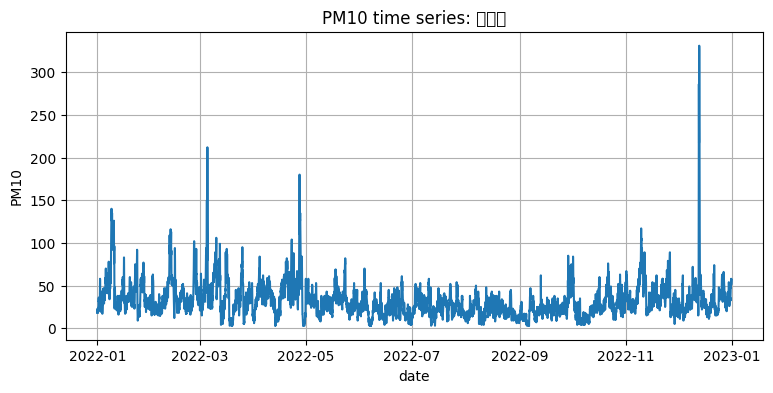

In [3]:

plt.figure(figsize=(9, 4))
plt.plot(area_df["date"], area_df["pm10"])
plt.title(f"PM10 time series: {target_area}")
plt.xlabel("date")
plt.ylabel("PM10")
plt.grid(True)
plt.show()


## window 데이터 만들기

21장과 동일하게 과거 24시간을 보고 다음 1시간을 예측한다.

입력 모양은 다음과 같다.

```text
(samples, timesteps, features)
```

여기서는:

```text
timesteps = 24
features = 1
```


In [4]:

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

def make_windows(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 24
X, y = make_windows(scaled_values, window_size=window_size)

# 시계열이므로 무작위 shuffle이 아니라 앞쪽을 train, 뒤쪽을 test로 둔다.
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (6988, 24, 1)
y_train: (6988,)
X_test: (1748, 24, 1)
y_test: (1748,)


## 모델 생성 함수

같은 입력 데이터에 대해 모델 종류만 바꾸기 위해 함수를 만든다.

모든 모델은 마지막에 `Dense(1)`을 붙여 다음 PM10 값 하나를 예측한다.


In [5]:

def build_sequence_model(kind, units=16):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

    if kind == "SimpleRNN":
        model.add(SimpleRNN(units))
    elif kind == "LSTM":
        model.add(LSTM(units))
    elif kind == "GRU":
        model.add(GRU(units))
    elif kind == "BiLSTM":
        # BiLSTM은 window 내부를 앞뒤 방향으로 읽는다.
        # 미래 예측 문제에서는 데이터 누출이 생기지 않도록 입력 window 밖의 미래를 넣지 않아야 한다.
        model.add(Bidirectional(LSTM(units)))
    else:
        raise ValueError(f"unknown model kind: {kind}")

    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model


## 모델 비교 실행

빠른 실행을 위해 epoch는 작게 둔다.

따라서 이 결과는 최종 성능 결론이 아니라, 비교 흐름을 배우기 위한 결과다.


In [6]:

def inverse_pm10(scaled_array):
    # scaler는 2차원 입력을 기대하므로 reshape 후 원래 PM10 단위로 되돌린다.
    return scaler.inverse_transform(np.asarray(scaled_array).reshape(-1, 1)).reshape(-1)

model_names = ["SimpleRNN", "LSTM", "GRU", "BiLSTM"]
results = []
predictions_by_model = {}

for name in model_names:
    print(f"Training {name}...")
    model = build_sequence_model(name, units=16)
    history = model.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=32,
        validation_split=0.2,
        verbose=0,
    )

    pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

    y_true_pm10 = inverse_pm10(y_test)
    y_pred_pm10 = inverse_pm10(pred_scaled)

    mae = mean_absolute_error(y_true_pm10, y_pred_pm10)
    rmse = mean_squared_error(y_true_pm10, y_pred_pm10) ** 0.5

    results.append({
        "model": name,
        "final_train_loss": history.history["loss"][-1],
        "final_val_loss": history.history["val_loss"][-1],
        "MAE_PM10": mae,
        "RMSE_PM10": rmse,
    })
    predictions_by_model[name] = y_pred_pm10

results_df = pd.DataFrame(results).sort_values("RMSE_PM10")
results_df


Training SimpleRNN...


Training LSTM...


Training GRU...


Training BiLSTM...


,model,final_train_loss,final_val_loss,MAE_PM10,RMSE_PM10
0,SimpleRNN,0.000325,0.000155,4.190276,8.112727
2,GRU,0.000473,0.000197,4.954840,9.603633
1,LSTM,0.000672,0.000284,6.052660,11.901991
3,BiLSTM,0.000785,0.000312,6.520810,12.783220


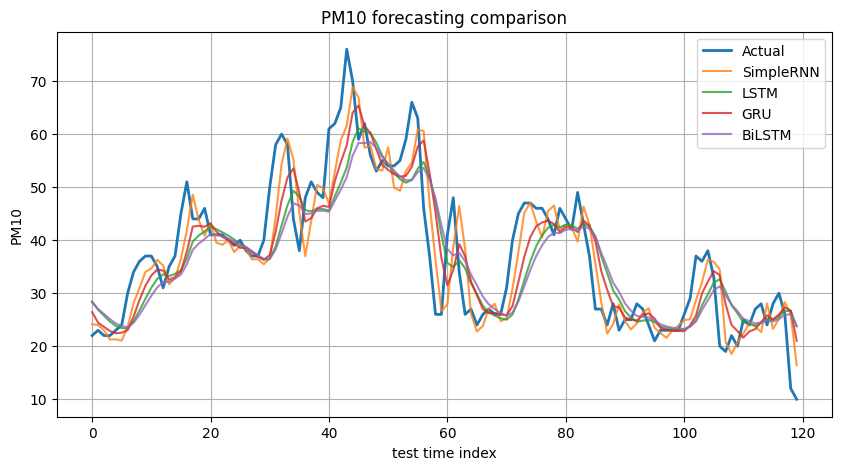

In [7]:

# 실제값과 각 모델의 예측값 일부를 그래프로 비교한다.
y_true_pm10 = inverse_pm10(y_test)
plot_count = min(120, len(y_true_pm10))

plt.figure(figsize=(10, 5))
plt.plot(y_true_pm10[:plot_count], label="Actual", linewidth=2)

for name in model_names:
    plt.plot(predictions_by_model[name][:plot_count], label=name, alpha=0.8)

plt.title("PM10 forecasting comparison")
plt.xlabel("test time index")
plt.ylabel("PM10")
plt.legend()
plt.grid(True)
plt.show()


## 결과를 해석할 때 주의할 점

결과 표에서 어떤 모델이 가장 좋아 보일 수 있다.

하지만 epoch를 작게 두었고, 한 번의 실행 결과만 본 것이므로 바로 최종 결론을 내리면 안 된다.

실제 프로젝트라면 다음을 더 확인해야 한다.

```text
여러 번 반복 실행
epoch 조정
units 조정
baseline과 비교
다른 기간에서도 성능 확인
데이터 누출 여부 확인
```

특히 BiLSTM은 미래 예측 문제에서 설명을 조심해야 한다.


In [8]:

best_row = results_df.iloc[0]
print("이번 실행에서 RMSE가 가장 낮은 모델:", best_row["model"])
print("RMSE:", best_row["RMSE_PM10"])
print()
print("주의: 이 결과는 작은 epoch 설정의 1회 실행 결과입니다. 최종 결론이 아닙니다.")


이번 실행에서 RMSE가 가장 낮은 모델: SimpleRNN
RMSE: 8.112727359824422

주의: 이 결과는 작은 epoch 설정의 1회 실행 결과입니다. 최종 결론이 아닙니다.


## 정리

이번 노트북의 핵심은 다음이다.

```text
같은 window 데이터
같은 train/test split
같은 평가 지표
모델 층만 교체
```

이렇게 비교하면 RNN 계열 모델을 실험하는 기본 흐름을 만들 수 있다.
